In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.constants as sc

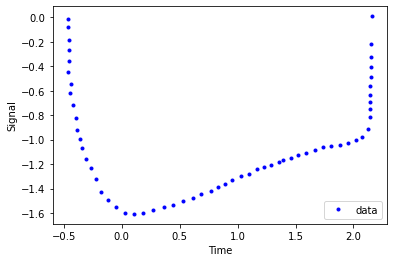

In [69]:
data  = np.loadtxt('pumping_data_4.csv', delimiter=',')
t = data[:,0]
V = data[:,1]


# plot
plt.plot(t, V, 'b.', label='data')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Signal")
plt.show()

tau_pump = 0.114  +/- 0.016
tau_relax = 0.0174  +/- 0.0046


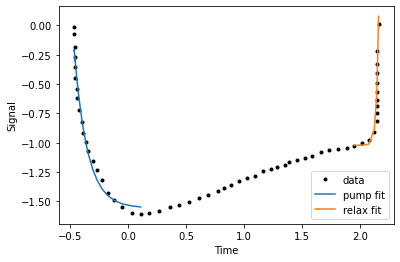

In [70]:
# ---------- LEFT: pumping ----------
def exp_decay(t, Vinf, A, tau, t0):
    return Vinf + A*np.exp(-(t - t0)/tau)

# ---------- RIGHT: relaxation ----------
def exp_rise(t, V_0, B, tau, t0):
    return B*np.exp((t - t0)/tau) + V_0

# choose region manually

mask_left = (t >= min(t)) & (t <= 0.15)
mask_right = (t >= 1.9) & (t <= max(t))

tL, VL = t[mask_left], V[mask_left]
tR, VR = t[mask_right], V[mask_right]

# plt.plot(tR, VR, 'b.', label='data')
# plt.legend()
# plt.xlabel("Time")
# plt.ylabel("Signal")
# plt.show()

# fits

p0L = [-2, (VL[0]-VL[-1])/10, 5e-2, 1]

poptL, pcovL = curve_fit(exp_decay, tL, VL, p0=p0L)
tau_pump = poptL[2]
tau_pump_err = np.sqrt(np.diag(pcovL))[2]


p0R = [-1, -1, 5e-3, tR[0]]

poptR, pcovR = curve_fit(exp_rise, tR, VR, p0=p0R)
tau_relax = poptR[2]
tau_relax_err = np.sqrt(np.diag(pcovR))[2]

print(f"tau_pump = {tau_pump:.3f}  +/- {tau_pump_err:.3f}")
print(f"tau_relax = {tau_relax:.4f}  +/- {tau_relax_err:.4f}")

# plot
tt = np.linspace(t.min(), t.max(), 500)
plt.plot(t, V, 'k.', label='data')
plt.plot(tL, exp_decay(tL, *poptL), label='pump fit')
plt.plot(tR, exp_rise(tR, *poptR), label='relax fit')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Signal")
plt.show()

# Separate graphs

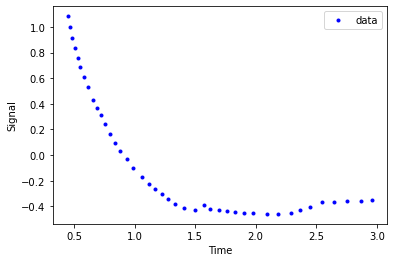

/var/folders/57/jv5dbbgn2lj2zgt76r3z7z140000gp/T/ipykernel_3133/895314808.py:3: RuntimeWarning: overflow encountered in exp
  return Vinf + A*np.exp(-(t - t0)/tau)


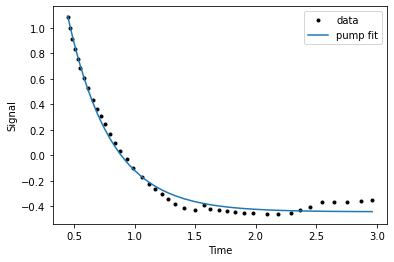

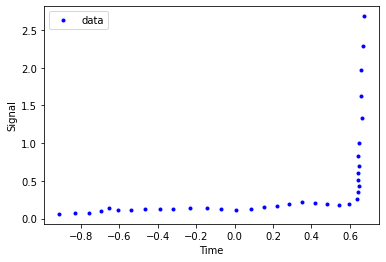

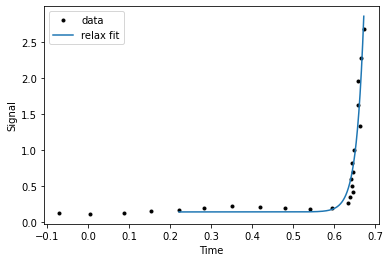

tau_pump = 17.7191  +/- 0.6219 ms
tau_relax = 0.8945  +/- 0.1249 ms


In [100]:
data_D  = np.loadtxt('decay_data.csv', delimiter=',')
t_D = data_D[:,0]
V_D = data_D[:,1]


# plot
plt.plot(t_D, V_D, 'b.', label='data')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Signal")
plt.savefig('pump_time_raw.png')
plt.show()

p0_D = [-0.4, (V_D[0]-V_D[-1])/10, 5e-2, 1]

popt_D, pcov_D = curve_fit(exp_decay, t_D, V_D, p0=p0_D)
tau_pump = popt_D[2]
tau_pump_err = np.sqrt(np.diag(pcov_D))[2]


# plot
tt_D = np.linspace(t_D.min(), t_D.max(), 500)
plt.plot(t_D, V_D, 'k.', label='data')
plt.plot(t_D, exp_decay(t_D, *popt_D), label='pump fit')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Signal")
plt.savefig('pump_time_fit.png')
plt.show()


data_R  = np.loadtxt('rise_data.csv', delimiter=',')
t_R = data_R[:,0]
V_R = data_R[:,1]

mid = int(len(t_R) *0.35)

mask_right = (t_R >= 0.2) & (t_R <= max(t_R))
tR, VR = t_R[mask_right], V_R[mask_right]



# plot
plt.plot(t_R, V_R, 'b.', label='data')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Signal")
plt.savefig('depump_time_raw.png')

plt.show()

p0_R = [0.2, (V_R[0]-V_R[-1])/10, 10e-2, 0.6]

poptR, pcovR = curve_fit(exp_rise, tR, VR, p0=p0_R)
tau_relax = poptR[2]
tau_relax_err = np.sqrt(np.diag(pcovR))[2]


# plot
tt_R = np.linspace(tR.min(), tR.max(), 1000)
plt.plot(t_R[mid:], V_R[mid:], 'k.', label='data')
#plt.plot(t_R[mask_right], V_R[mask_right], 'k.', label='data')
plt.plot(tt_R, exp_rise(tt_R, *poptR), label='relax fit')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Signal")
plt.savefig('depump_time_fit.png')
plt.show()


print(f"tau_pump = {tau_pump*50:.4f}  +/- {tau_pump_err*50:.4f} ms")
print(f"tau_relax = {tau_relax*50:.4f}  +/- {tau_relax_err*50:.4f} ms")


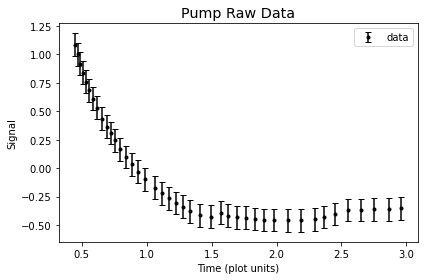

/var/folders/57/jv5dbbgn2lj2zgt76r3z7z140000gp/T/ipykernel_3133/4214699139.py:17: RuntimeWarning: overflow encountered in exp
  return C + A * np.exp(-(t - t0) / tau)


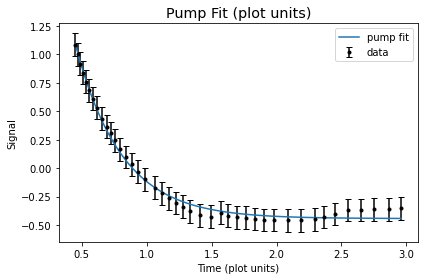

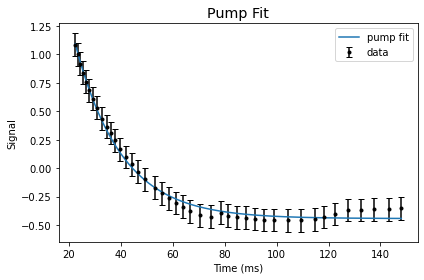

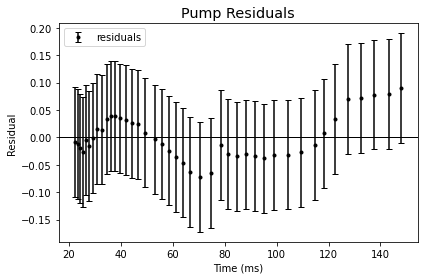

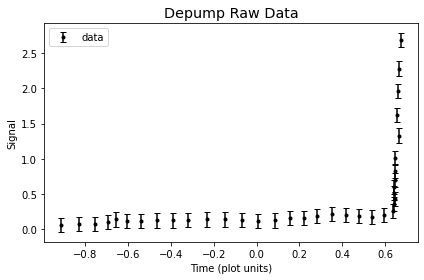

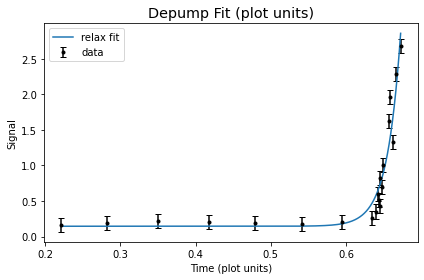

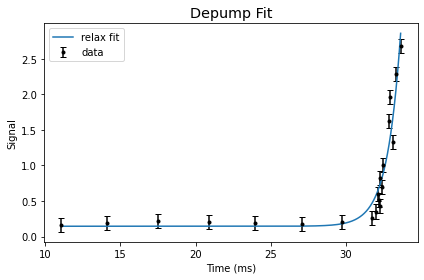

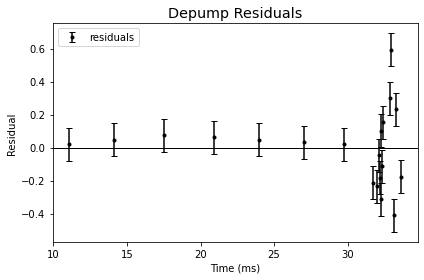

=== Pump / Decay Fit ===
C              = -0.442121 ± 0.026940
A              = 0.320675 ± 1281525.045589
tau            = 17.7191 ± 1.4692 ms
tau (scaled)   = 17.7191 ± 0.6215 ms
t0             = 50.1834 ± 70765340.6964 ms
t0 (scaled)    = 50.1834 ± 29936380.2245 ms
chi^2          = 6.8005
dof            = 38
reduced chi^2  = 0.1790
p-value        = 1.0000
scale factor   = 0.4230

=== Relaxation / Rise Fit ===
C              = 0.144745 ± 0.039146
A              = 0.006261 ± 53072.399470
tau            = 0.8945 ± 0.0804 ms
tau (scaled)   = 0.8945 ± 0.2003 ms
t0             = 28.1891 ± 7593623.5809 ms
t0 (scaled)    = 28.1891 ± 18915921.3187 ms
chi^2          = 99.2834
dof            = 16
reduced chi^2  = 6.2052
p-value        = 4.7184e-14
scale factor   = 2.4910


In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

# ============================================================
# time-axis conversion
# 1 plotted time unit = 50 ms
# ============================================================
TIME_SCALE_MS = 50.0   # ms per x-axis unit


# ============================================================
# model functions
# ============================================================
def exp_decay(t, C, A, tau, t0):
    return C + A * np.exp(-(t - t0) / tau)

def exp_rise(t, V_0, B, tau, t0):
    return B*np.exp((t - t0)/tau) + V_0


# ============================================================
# helper functions
# ============================================================
def compute_fit_stats(x, y, sigma_y, model, popt):
    y_fit = model(x, *popt)
    residuals = y - y_fit
    norm_residuals = residuals / sigma_y

    chi2_val = np.sum((residuals / sigma_y)**2)
    n_params = len(popt)
    dof = len(y) - n_params
    red_chi2 = chi2_val / dof
    p_val = chi2.sf(chi2_val, dof)
    scale_factor = np.sqrt(red_chi2)

    return {
        "y_fit": y_fit,
        "residuals": residuals,
        "norm_residuals": norm_residuals,
        "chi2": chi2_val,
        "dof": dof,
        "red_chi2": red_chi2,
        "p_val": p_val,
        "scale_factor": scale_factor,
    }


def rescale_time_params(popt, pcov, time_scale_ms):
    """
    Rescale the time-like fit parameters from x-axis units to ms.
    Assumes parameter order: [C, A, tau, t0]
    """
    popt_ms = popt.copy()
    pcov_ms = pcov.copy()

    # Rescale tau and t0
    popt_ms[2] *= time_scale_ms
    popt_ms[3] *= time_scale_ms

    # Covariance scaling:
    # var(a x) = a^2 var(x), cov(a x, b y) = ab cov(x,y)
    scale_vec = np.array([1.0, 1.0, time_scale_ms, time_scale_ms])
    pcov_ms = pcov * np.outer(scale_vec, scale_vec)

    return popt_ms, pcov_ms


# ============================================================
# DECAY FIT
# ============================================================
data_D = np.loadtxt("decay_data.csv", delimiter=",")
t_D = data_D[:, 0]
V_D = data_D[:, 1]

# Estimated y error from manual digitization
sigma_V_D = np.full_like(V_D, 0.1, dtype=float)

# Raw data plot
plt.errorbar(t_D, V_D, yerr=sigma_V_D, fmt='k.', capsize=3, label='data')
plt.xlabel("Time (plot units)")
plt.ylabel("Signal")
plt.title('Pump Raw Data',fontsize='x-large')
plt.legend()
plt.tight_layout()
plt.savefig("pump_time_raw.png", dpi=300)
plt.show()

p0_D = [-0.4, (V_D[0] - V_D[-1]) / 10, 5e-2, 1]

popt_D, pcov_D = curve_fit(
    exp_decay,
    t_D,
    V_D,
    p0=p0_D,
    sigma=sigma_V_D,
    absolute_sigma=True,
    maxfev=10000
)

stats_D = compute_fit_stats(t_D, V_D, sigma_V_D, exp_decay, popt_D)

# Unscaled errors
perr_D = np.sqrt(np.diag(pcov_D))

# Scaled covariance and errors
pcov_D_scaled = pcov_D * stats_D["red_chi2"]
perr_D_scaled = np.sqrt(np.diag(pcov_D_scaled))

# Rescale time parameters to ms
popt_D_ms, pcov_D_ms = rescale_time_params(popt_D, pcov_D, TIME_SCALE_MS)
perr_D_ms = np.sqrt(np.diag(pcov_D_ms))

popt_D_scaled_ms, pcov_D_scaled_ms = rescale_time_params(
    popt_D, pcov_D_scaled, TIME_SCALE_MS
)
perr_D_scaled_ms = np.sqrt(np.diag(pcov_D_scaled_ms))

# Fit plot in plot units
tt_D = np.linspace(t_D.min(), t_D.max(), 500)
plt.errorbar(t_D, V_D, yerr=sigma_V_D, fmt='k.', capsize=3, label='data')
plt.plot(tt_D, exp_decay(tt_D, *popt_D), label='pump fit')
plt.xlabel("Time (plot units)")
plt.ylabel("Signal")
plt.title('Pump Fit (plot units)',fontsize='x-large')
plt.legend()
plt.tight_layout()
plt.savefig("pump_time_fit.png", dpi=300)
plt.show()

# Fit plot in ms
tt_D_ms = tt_D * TIME_SCALE_MS
plt.errorbar(t_D * TIME_SCALE_MS, V_D, yerr=sigma_V_D, fmt='k.', capsize=3, label='data')
plt.plot(tt_D_ms, exp_decay(tt_D, *popt_D), label='pump fit')
plt.xlabel("Time (ms)")
plt.ylabel("Signal")
plt.title('Pump Fit',fontsize='x-large')
plt.legend()
plt.tight_layout()
plt.savefig("pump_time_fit_ms.png", dpi=300)
plt.show()

# Residuals
plt.axhline(0, color='k', lw=1)
plt.errorbar(
    t_D * TIME_SCALE_MS,
    stats_D["residuals"],
    yerr=sigma_V_D,
    fmt='k.',
    capsize=3,
    label='residuals'
)
plt.xlabel("Time (ms)")
plt.ylabel("Residual")
plt.title('Pump Residuals',fontsize='x-large')
plt.legend()
plt.tight_layout()
plt.savefig("pump_time_residuals.png", dpi=300)
plt.show()


# ============================================================
# RISE FIT
# ============================================================
data_R = np.loadtxt("rise_data.csv", delimiter=",")
t_R = data_R[:, 0]
V_R = data_R[:, 1]

mask_right = (t_R >= 0.2) & (t_R <= np.max(t_R))
tR = t_R[mask_right]
VR = V_R[mask_right]

sigma_V_R_full = np.full_like(V_R, 0.1, dtype=float)
sigma_V_R = sigma_V_R_full[mask_right]

# Raw data plot
plt.errorbar(t_R, V_R, yerr=sigma_V_R_full, fmt='k.', capsize=3, label='data')
plt.xlabel("Time (plot units)")
plt.ylabel("Signal")
plt.title('Depump Raw Data',fontsize='x-large')
plt.legend()
plt.tight_layout()
plt.savefig("depump_time_raw.png", dpi=300)
plt.show()

p0_R = [0.2, (VR[0] - VR[-1]) / 10, 10e-2, 0.6]

popt_R, pcov_R = curve_fit(
    exp_rise,
    tR,
    VR,
    p0=p0_R,
    sigma=sigma_V_R,
    absolute_sigma=True,
    maxfev=10000
)

stats_R = compute_fit_stats(tR, VR, sigma_V_R, exp_rise, popt_R)

# Unscaled errors
perr_R = np.sqrt(np.diag(pcov_R))

# Scaled covariance and errors
pcov_R_scaled = pcov_R * stats_R["red_chi2"]
perr_R_scaled = np.sqrt(np.diag(pcov_R_scaled))

# Rescale time parameters to ms
popt_R_ms, pcov_R_ms = rescale_time_params(popt_R, pcov_R, TIME_SCALE_MS)
perr_R_ms = np.sqrt(np.diag(pcov_R_ms))

popt_R_scaled_ms, pcov_R_scaled_ms = rescale_time_params(
    popt_R, pcov_R_scaled, TIME_SCALE_MS
)
perr_R_scaled_ms = np.sqrt(np.diag(pcov_R_scaled_ms))

# Fit plot in plot units
tt_R = np.linspace(tR.min(), tR.max(), 1000)
plt.errorbar(tR, VR, yerr=sigma_V_R, fmt='k.', capsize=3, label='data')
plt.plot(tt_R, exp_rise(tt_R, *popt_R), label='relax fit')
plt.xlabel("Time (plot units)")
plt.ylabel("Signal")
plt.title('Depump Fit (plot units)',fontsize='x-large')
plt.legend()
plt.tight_layout()
plt.savefig("depump_time_fit.png", dpi=300)
plt.show()

# Fit plot in ms
tt_R_ms = tt_R * TIME_SCALE_MS
plt.errorbar(tR * TIME_SCALE_MS, VR, yerr=sigma_V_R, fmt='k.', capsize=3, label='data')
plt.plot(tt_R_ms, exp_rise(tt_R, *popt_R), label='relax fit')
plt.xlabel("Time (ms)")
plt.ylabel("Signal")
plt.title('Depump Fit',fontsize='x-large')
plt.legend()
plt.tight_layout()
plt.savefig("depump_time_fit_ms.png", dpi=300)
plt.show()

# Residuals
plt.axhline(0, color='k', lw=1)
plt.errorbar(
    tR * TIME_SCALE_MS,
    stats_R["residuals"],
    yerr=sigma_V_R,
    fmt='k.',
    capsize=3,
    label='residuals'
)
plt.xlabel("Time (ms)")
plt.ylabel("Residual")
plt.title('Depump Residuals',fontsize='x-large')
plt.legend()
plt.tight_layout()
plt.savefig("depump_time_residuals.png", dpi=300)
plt.show()


# ============================================================
# PRINT RESULTS
# ============================================================
print("=== Pump / Decay Fit ===")
print(f"C              = {popt_D[0]:.6f} ± {perr_D[0]:.6f}")
print(f"A              = {popt_D[1]:.6f} ± {perr_D[1]:.6f}")
print(f"tau            = {popt_D_ms[2]:.4f} ± {perr_D_ms[2]:.4f} ms")
print(f"tau (scaled)   = {popt_D_scaled_ms[2]:.4f} ± {perr_D_scaled_ms[2]:.4f} ms")
print(f"t0             = {popt_D_ms[3]:.4f} ± {perr_D_ms[3]:.4f} ms")
print(f"t0 (scaled)    = {popt_D_scaled_ms[3]:.4f} ± {perr_D_scaled_ms[3]:.4f} ms")
print(f"chi^2          = {stats_D['chi2']:.4f}")
print(f"dof            = {stats_D['dof']}")
print(f"reduced chi^2  = {stats_D['red_chi2']:.4f}")
print(f"p-value        = {stats_D['p_val']:.4f}")
print(f"scale factor   = {stats_D['scale_factor']:.4f}")

print('')
print("=== Relaxation / Rise Fit ===")
print(f"C              = {popt_R[0]:.6f} ± {perr_R[0]:.6f}")
print(f"A              = {popt_R[1]:.6f} ± {perr_R[1]:.6f}")
print(f"tau            = {popt_R_ms[2]:.4f} ± {perr_R_ms[2]:.4f} ms")
print(f"tau (scaled)   = {popt_R_scaled_ms[2]:.4f} ± {perr_R_scaled_ms[2]:.4f} ms")
print(f"t0             = {popt_R_ms[3]:.4f} ± {perr_R_ms[3]:.4f} ms")
print(f"t0 (scaled)    = {popt_R_scaled_ms[3]:.4f} ± {perr_R_scaled_ms[3]:.4f} ms")
print(f"chi^2          = {stats_R['chi2']:.4f}")
print(f"dof            = {stats_R['dof']}")
print(f"reduced chi^2  = {stats_R['red_chi2']:.4f}")
print(f"p-value        = {stats_R['p_val']:.4e}")
print(f"scale factor   = {stats_R['scale_factor']:.4f}")

In [110]:
from scipy.optimize import curve_fit
from scipy.stats import chi2
import numpy as np

def refit_with_scaled_errors(x, y, sigma_y, model, p0, popt_initial):
    # First-pass statistics
    y_fit = model(x, *popt_initial)
    resid = y - y_fit

    chi2_val = np.sum((resid / sigma_y)**2)
    dof = len(y) - len(popt_initial)
    red_chi2 = chi2_val / dof
    scale_factor = np.sqrt(red_chi2)

    # Rescale the y-errors
    sigma_y_scaled = sigma_y * scale_factor

    # Refit
    popt2, pcov2 = curve_fit(
        model,
        x,
        y,
        p0=popt_initial,
        sigma=sigma_y_scaled,
        absolute_sigma=True,
        maxfev=10000
    )

    # Recompute stats
    y_fit2 = model(x, *popt2)
    resid2 = y - y_fit2
    chi2_val2 = np.sum((resid2 / sigma_y_scaled)**2)
    red_chi2_2 = chi2_val2 / dof
    p_val2 = chi2.sf(chi2_val2, dof)
    perr2 = np.sqrt(np.diag(pcov2))

    return {
        "popt": popt2,
        "pcov": pcov2,
        "perr": perr2,
        "sigma_y_scaled": sigma_y_scaled,
        "chi2": chi2_val2,
        "dof": dof,
        "red_chi2": red_chi2_2,
        "p_val": p_val2,
        "scale_factor": scale_factor,
        "residuals": resid2,
        "y_fit": y_fit2,
    }

In [111]:
result_D_refit = refit_with_scaled_errors(
    t_D, V_D, sigma_V_D, exp_decay, p0_D, popt_D
)

print("=== Pump refit with scaled errors ===")
print("scale factor =", result_D_refit["scale_factor"])
print("chi^2        =", result_D_refit["chi2"])
print("dof          =", result_D_refit["dof"])
print("reduced chi^2=", result_D_refit["red_chi2"])
print("p-value      =", result_D_refit["p_val"])
print("tau          =", result_D_refit["popt"][2], "+/-", result_D_refit["perr"][2])


print('')



result_R_refit = refit_with_scaled_errors(
    tR, VR, sigma_V_R, exp_rise, p0_R, popt_R
)

print("=== Relax refit with scaled errors ===")
print("scale factor =", result_R_refit["scale_factor"])
print("chi^2        =", result_R_refit["chi2"])
print("dof          =", result_R_refit["dof"])
print("reduced chi^2=", result_R_refit["red_chi2"])
print("p-value      =", result_R_refit["p_val"])
print("tau          =", result_R_refit["popt"][2], "+/-", result_R_refit["perr"][2])

=== Pump refit with scaled errors ===
scale factor = 0.4230373220827149
chi^2        = 37.99999999999999
dof          = 38
reduced chi^2= 0.9999999999999998
p-value      = 0.4694842569230965
tau          = 0.35438170299100763 +/- 0.012441543283965557

=== Relax refit with scaled errors ===
scale factor = 2.4910269935107934
chi^2        = 15.999999999649763
dof          = 16
reduced chi^2= 0.9999999999781102
p-value      = 0.45296080951143847
tau          = 0.017890997920384386 +/- 0.0029991557538375686


In [119]:
# comparison

B_plus_85 = 0.3537
B_plus_85_err = 0.0461

B_minus_85 = 0.4124
B_minus_85_err = 0.0915

B_plus_87 = 0.2153
B_plus_87_err = 0.1614

B_minus_87 = 0.3856
B_minus_87_err = 0.0175

B_ave_85 = 0.394 
B_ave_85_err = 0.006 

B_ave_87 = 0.380 
B_ave_87_err = 0.012


B_V_85 = 0.3953
B_V_85_err =  0.0063

B_V_87 = 0.3797
B_V_87_err = 0.0117


B_zero_field = 0.493024
B_zero_field_err = 0.014203

B_zero_field_2 = 0.5036
B_zero_field_2_err = 0.033


B_true = 0.49361



def compare(name, B, B_err):
    diff = B - B_true
    abs_diff = abs(diff)
    pull = diff / B_err
    percent_diff = abs_diff / B_true * 100

    print(f"--- {name} ---")
    print(f"B = {B:.4f} ± {B_err:.4f} G")
    print(f"Deviation = {diff:.4f} G")
    print(f"|Deviation| = {abs_diff:.4f} G")
    print(f"Percent difference = {percent_diff:.2f}%")
    print(f"Pull = {pull:.2f} σ")

    if abs(pull) < 1:
        print("Agreement: consistent (within 1σ)")
    elif abs(pull) < 2:
        print("Agreement: marginal (within 2σ)")
    else:
        print("Agreement: NOT consistent")
    print()


# Rb85
compare("Rb85 B+", B_plus_85, B_plus_85_err)
compare("Rb85 B-", B_minus_85, B_minus_85_err)
compare("Rb85 avg", B_ave_85, B_ave_85_err)
compare("Rb85 V-fit", B_V_85, B_V_85_err)

# Rb87
compare("Rb87 B+", B_plus_87, B_plus_87_err)
compare("Rb87 B-", B_minus_87, B_minus_87_err)
compare("Rb87 avg", B_ave_87, B_ave_87_err)
compare("Rb87 V-fit", B_V_87, B_V_87_err)

# zero-field measurement
compare("Zero-field Method 1", B_zero_field, B_zero_field_err)
compare("Zero-field Method 2", B_zero_field_2, B_zero_field_2_err)

--- Rb85 B+ ---
B = 0.3537 ± 0.0461 G
Deviation = -0.1399 G
|Deviation| = 0.1399 G
Percent difference = 28.34%
Pull = -3.03 σ
Agreement: NOT consistent

--- Rb85 B- ---
B = 0.4124 ± 0.0915 G
Deviation = -0.0812 G
|Deviation| = 0.0812 G
Percent difference = 16.45%
Pull = -0.89 σ
Agreement: consistent (within 1σ)

--- Rb85 avg ---
B = 0.3940 ± 0.0060 G
Deviation = -0.0996 G
|Deviation| = 0.0996 G
Percent difference = 20.18%
Pull = -16.60 σ
Agreement: NOT consistent

--- Rb85 V-fit ---
B = 0.3953 ± 0.0063 G
Deviation = -0.0983 G
|Deviation| = 0.0983 G
Percent difference = 19.92%
Pull = -15.60 σ
Agreement: NOT consistent

--- Rb87 B+ ---
B = 0.2153 ± 0.1614 G
Deviation = -0.2783 G
|Deviation| = 0.2783 G
Percent difference = 56.38%
Pull = -1.72 σ
Agreement: marginal (within 2σ)

--- Rb87 B- ---
B = 0.3856 ± 0.0175 G
Deviation = -0.1080 G
|Deviation| = 0.1080 G
Percent difference = 21.88%
Pull = -6.17 σ
Agreement: NOT consistent

--- Rb87 avg ---
B = 0.3800 ± 0.0120 G
Deviation = -0.1136 G
|

In [113]:
# data
nu = np.array([0.22991, 0.22999, 0.23001, 0.23002, 0.230004, 0.23])
nu_err = np.array([0.02, 0.02, 0.015, 0.015, 0.015, 0.015])

# weights
w = 1 / nu_err**2

# weighted average (frequency)
nu_avg = np.sum(w * nu) / np.sum(w)
nu_avg_err = np.sqrt(1 / np.sum(w))

# convert to B
B_avg = nu_avg / 0.4665
B_avg_err = nu_avg_err / 0.4665

print(f"B_avg = {B_avg:.6f} ± {B_avg_err:.6f} G")

B_avg = 0.493024 ± 0.014203 G


In [118]:
print(f'{sc.m_e/sc.m_p:.5e}')

5.44617e-04
